In [28]:
import sys
import os
import pandas as pd

sys.path.append('../src/scripts')
sys.path.append('../src/classes')
from simulation import Simulation
from config import get_simulation_number
from data_scraping_in_results import scraper

In [29]:
mobility_file_path = '../src/sumo/csv/train_single.csv'
edge_file_path = '../src/inputs/train/edge_servers.json'
vehicle_file_path = '../src/inputs/train/vehicles_single.json'


In [ ]:
_proposed="proposed"
_local= "local_only"
_offload = "offload_only"
_random = "random"
algorithms = [_proposed,_local,_offload,_random]
simulation_number = 69
report_paths = {}

for a in algorithms:
    report_paths[a] = ('../results/reports/'+str(simulation_number)+'_report_'+a+'_test.csv')
q_table_path = '../results/q_table/'+str(simulation_number)+'_q_table_proposed'

#overwrite specific report addresses for proposed
proposed_test_sim_number=69
proposed_test_number=1
if(proposed_test_number != 'train'):
    report_paths[_proposed]='../results/reports/'+str(proposed_test_sim_number)+'_report_'+_proposed+'_test_'+str(proposed_test_number)+'.csv'
else:
    report_paths[_proposed]='../results/reports/'+str(proposed_test_sim_number)+'_report_'+_proposed+'_train.csv'


num_of_cars=20
end_time_limit=-1
# should_update_q_table = False
print(report_paths)

{'proposed': '../results/reports/69_report_proposed_test_1.csv', 'local_only': '../results/reports/69_report_local_only_test.csv', 'offload_only': '../results/reports/69_report_offload_only_test.csv', 'random': '../results/reports/69_report_random_test.csv'}


In [31]:
scrapers={}
for a in algorithms:
    scrapers[a] = scraper(report_paths[a],num_of_cars,end_time_limit)

---------------------------------------------
../results/reports/69_report_proposed_test_1.csv
No time limit
Header --->
   vehicle_id  task_id  execution_location      size    distance  \
0           1        1                   1   2000000  193.826094   
1           1        2                   1   4000000  184.436507   
2           1        3                   0  10000000  165.883824   
3           1        4                   1   8000000  137.678077   
4           1        5                   1   2000000  112.105098   

   transfer_rate  execution_cycles  start_time  end_time  release_time  \
0   9.519803e+05        8000000000        2102      3702             1   
1   1.159480e+06        2000000000        6451      6851          3001   
2   0.000000e+00        5000000000        6001     11001          6001   
3   3.669390e+06        8000000000       13623     15223          9001   
4   8.092026e+06        6000000000       15223     16423         12001   

   response_time  transmi

In [32]:
averages = {}
for a in algorithms:
    print("=========================================")
    print(a,"------->")
    averages[a] = scrapers[a].calc_average_all(False)

final_df = pd.concat(averages, names=['Algorithm'])
print(final_df)



proposed ------->
local_only ------->
offload_only ------->
random ------->
Algorithm                  
proposed      response_time     25435.908776
              total_energy          0.715810
local_only    response_time    255252.786984
              total_energy          0.599638
offload_only  response_time     80419.074563
              total_energy          1.233830
random        response_time     22411.407836
              total_energy          0.898276
dtype: float64


In [33]:
for a in algorithms:
    print("=========================================")
    print(a,"----------AVERAGED----->")
    scrapers[a].calc_average_for_each_car()

proposed ----------AVERAGED----->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1            29590.176282        1919.903846     2267.948718   
2            25220.247492        2222.301003     2317.725753   
3            19596.768072        1429.463855     2330.722892   
4            32181.993421        1564.101974     2228.289474   
5            22620.459375        2145.643750     2588.125000   
6            24372.708333        2199.551282     2529.487179   
7            23716.953642        1714.006623     2367.549669   
8            22514.847095        2259.571865     2354.740061   
9             7408.645646        1572.576577     2127.927928   
10           34861.259615        1866.817308     2087.179487   
11           19389.096677        1983.347432     2264.048338   
12           27368.978328        1999.012384     2250.154799   
13           24937.036585        1790.923780     2224.390244   
14    

In [34]:
for a in algorithms:
    print("=========================================")
    print(a,"----TOTAL------->")
    scrapers[a].calc_sum_for_each_car()

proposed ----TOTAL------->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1                 9232135             599010          707600   
2                 7540854             664468          693000   
3                 6506127             474582          773800   
4                 9783326             475487          677400   
5                 7238547             686606          828200   
6                 7604285             686260          789200   
7                 7162520             517630          715000   
8                 7362355             738880          770000   
9                 2467079             523668          708600   
10               10876713             582447          651200   
11                6417791             656488          749400   
12                8840180             645681          726800   
13                8179348             587423          729600   
14           

proposed -------AVERAGE----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1107             1106.0              306.0           800.0               0.0   
1871             1870.0               70.0          1800.0               0.0   
1936             1935.0              935.0          1000.0               0.0   
2001             2000.0                0.0          2000.0               0.2   
2534             2533.0             1733.0           800.0               0.0   
...                 ...                ...             ...               ...   
999128         159127.0             2663.0          1600.0               0.0   
999650          96649.0              241.0          1000.0               0.0   
999728         159727.0             3474.0           600.0               0.0   
999890          12889.0             2774.0          1600.0               0.0   
999937    

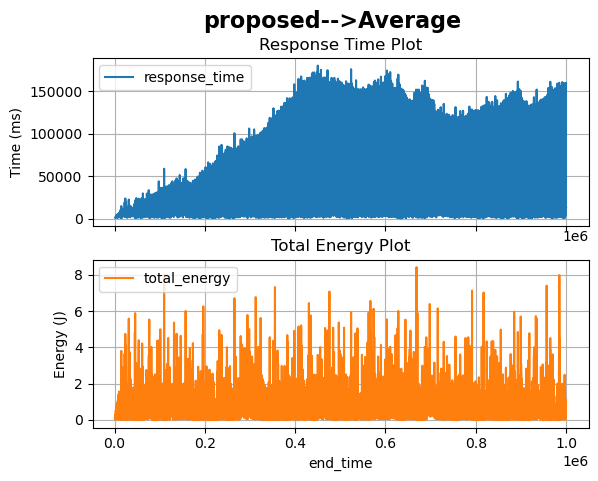

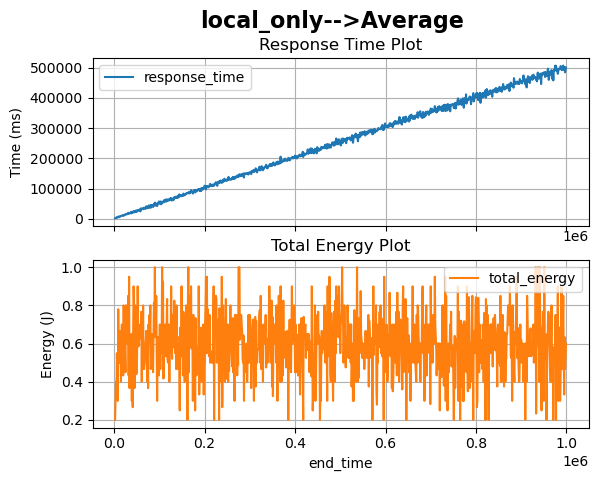

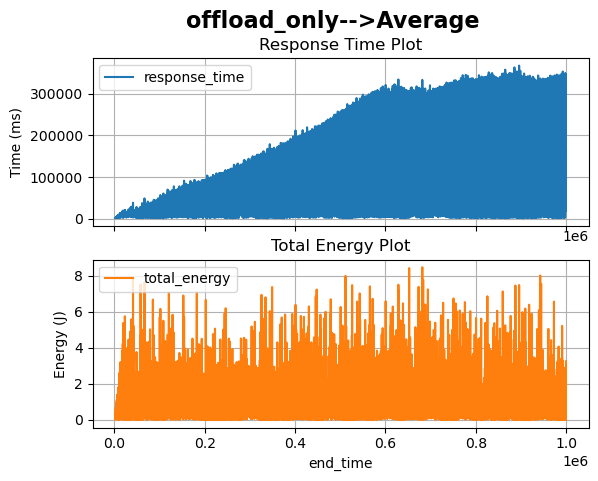

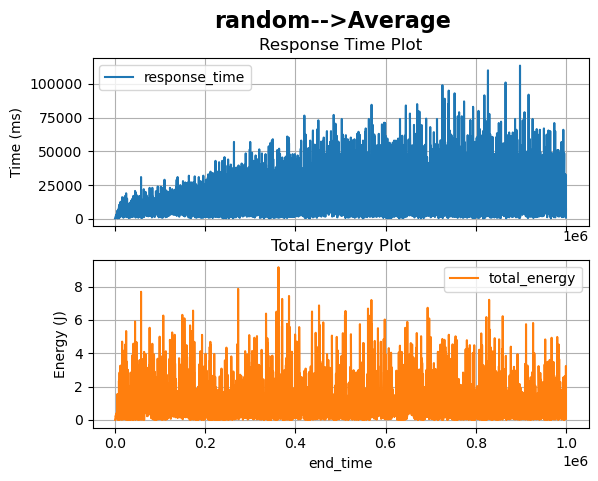

In [35]:
for a in algorithms:
    print("=========================================")
    print(a,"-------AVERAGE----->")
    scrapers[a].calc_average_for_each_end_time(plot=True,plot_title=a+"-->"+"Average")

proposed -------SUM----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1107               1106                306             800               0.0   
1871               1870                 70            1800               0.0   
1936               1935                935            1000               0.0   
2001               4000                  0            4000               0.4   
2534               2533               1733             800               0.0   
...                 ...                ...             ...               ...   
999128           159127               2663            1600               0.0   
999650            96649                241            1000               0.0   
999728           159727               3474             600               0.0   
999890            12889               2774            1600               0.0   
999937        

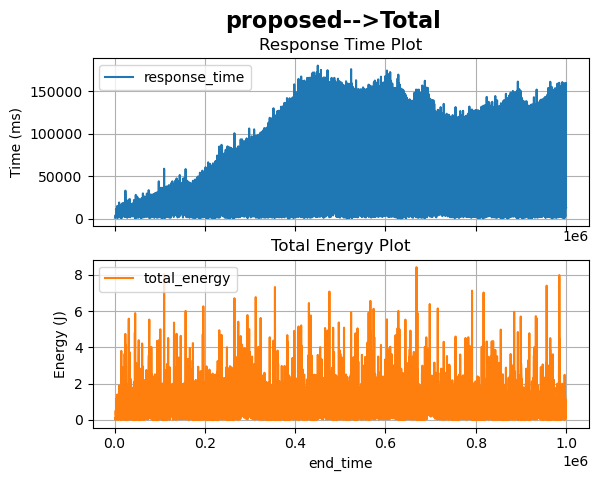

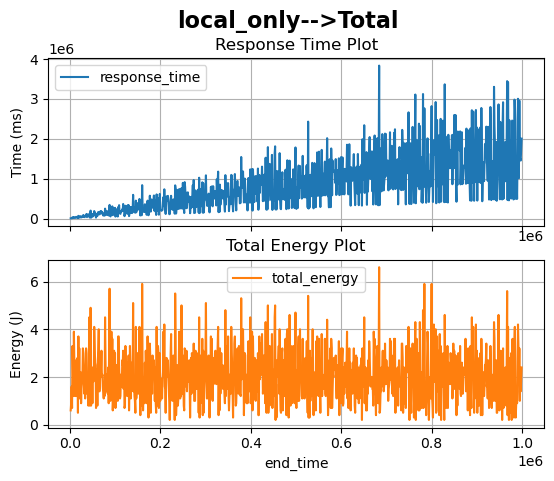

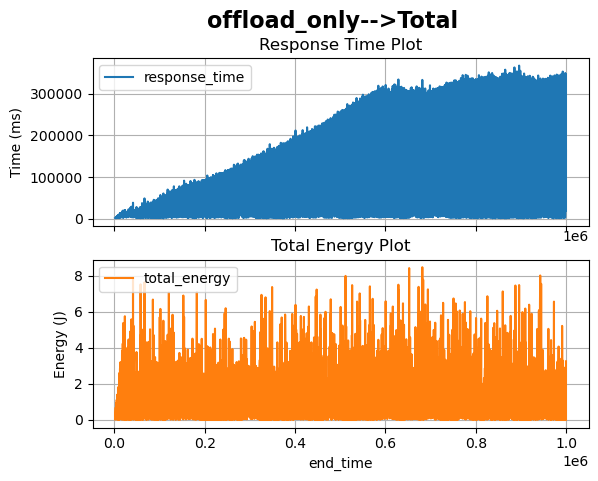

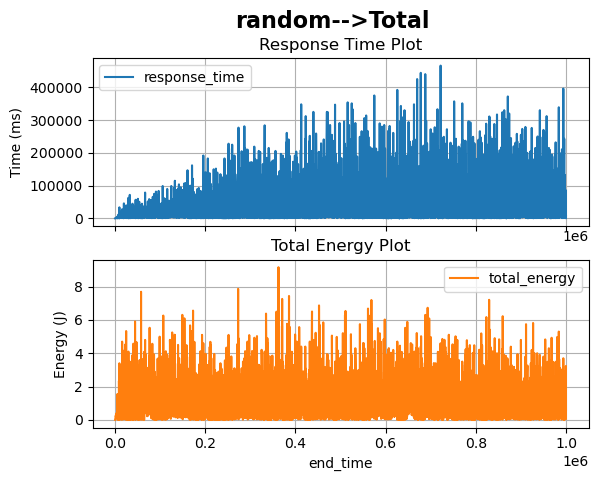

In [36]:
for a in algorithms:
    print("=========================================")
    print(a,"-------SUM----->")
    scrapers[a].calc_sum_for_each_end_time(plot=True,plot_title=a+"-->"+"Total")